# Data Exploration Notebook

## CodeDocGen


In [13]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import re

In [ ]:
# Set visualization style
plt.style.use('ggplot')
sns.set(font_scale=1.1)

In [15]:
from datasets import load_dataset

# Load only Python code from CodeSearchNet
dataset = load_dataset("code_search_net", "python")

#### Dataset Overview 

In [18]:
# Examine Dataset Structure
print("\n--- Dataset Structure ---")
print(dataset)
print(f"Available splits: {dataset.keys()}")

# Dataset Statistics
print("\n--- Dataset Statistics ---")
print(f"Training examples: {len(dataset['train'])}")
print(f"Validation examples: {len(dataset['validation'])}")
print(f"Test examples: {len(dataset['test'])}")

# Examine Feature Structure
print("\n--- Feature Structure ---")
print(dataset['train'].features)



--- Dataset Structure ---
DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 23107
    })
})
Available splits: dict_keys(['train', 'test', 'validation'])

--- Datase

#### Create Sample Entry from training set

In [19]:
print("--- Sample Entry from Training Set ---")
sample_entry = dataset['train'][0]
for key, value in sample_entry.items():
    if isinstance(value, list):
        print(f"{key}: List with {len(value)} items")
    else:
        if key != 'whole_func_string' and key != 'func_code_string':  # Skip printing the full code
            print(f"{key}: {value}")

--- Sample Entry from Training Set ---
repository_name: proycon/pynlpl
func_path_in_repository: pynlpl/formats/folia.py
func_name: AbstractElement.addidsuffix
language: python
func_code_tokens: List with 44 items
func_documentation_string: Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked implicitly by :meth:`copy`
func_documentation_tokens: List with 33 items
split_name: train
func_code_url: https://github.com/proycon/pynlpl/blob/7707f69a91caaa6cde037f0d0379f1d42500a68b/pynlpl/formats/folia.py#L1263-L1271


#### DataFrame


In [20]:
#Convert to DataFrame for easier analysis
print("\n--- Converting to DataFrame for Analysis ---")
# We'll use a sample for initial exploration to keep it manageable
sample_size = 10000
train_sample = dataset['train'].shuffle(seed=42).select(range(sample_size))
train_df = pd.DataFrame(train_sample)



--- Converting to DataFrame for Analysis ---


In [21]:
#  Data Statistics
print("\n--- Basic Data Stats ---")
# Look at the distribution of repositories
repo_counts = train_df['repository_name'].value_counts().head(10)
print("Top 10 repositories in the dataset:")
print(repo_counts)


--- Basic Data Stats ---
Top 10 repositories in the dataset:
repository_name
saltstack/salt                    215
mitsei/dlkit                       60
materialsproject/pymatgen          56
apple/turicreate                   53
brocade/pynos                      50
tensorflow/tensor2tensor           47
googleapis/google-cloud-python     44
iotile/coretools                   42
pypa/pipenv                        41
gem/oq-engine                      41
Name: count, dtype: int64


#### Visualizations


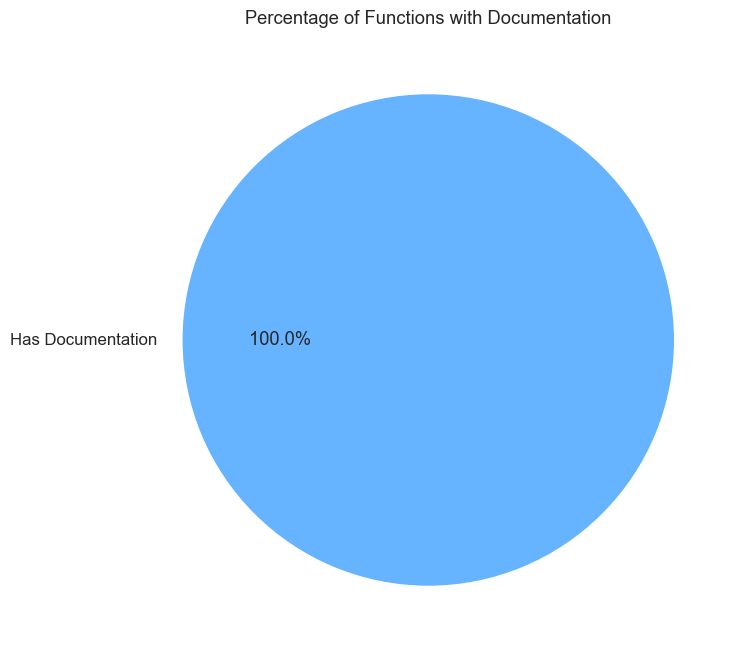

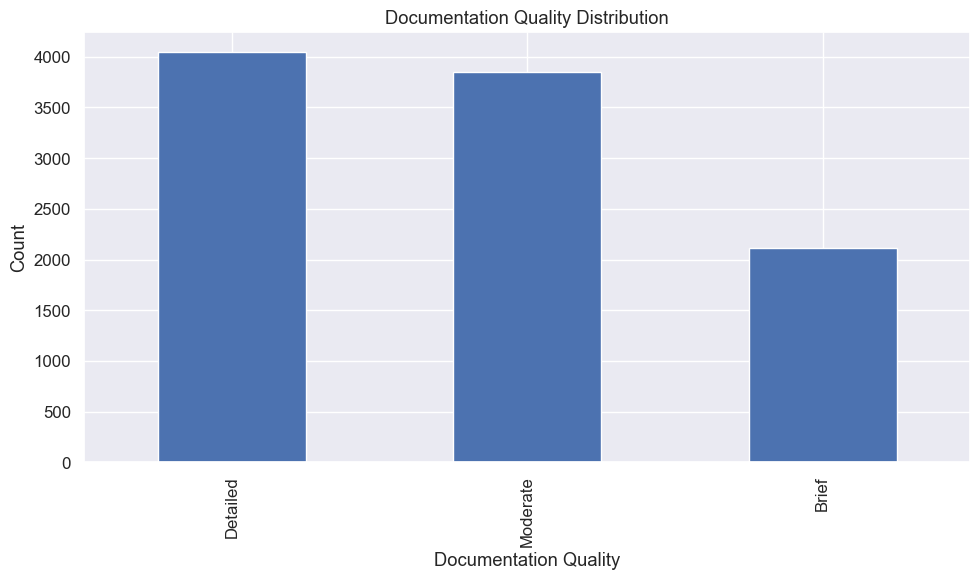

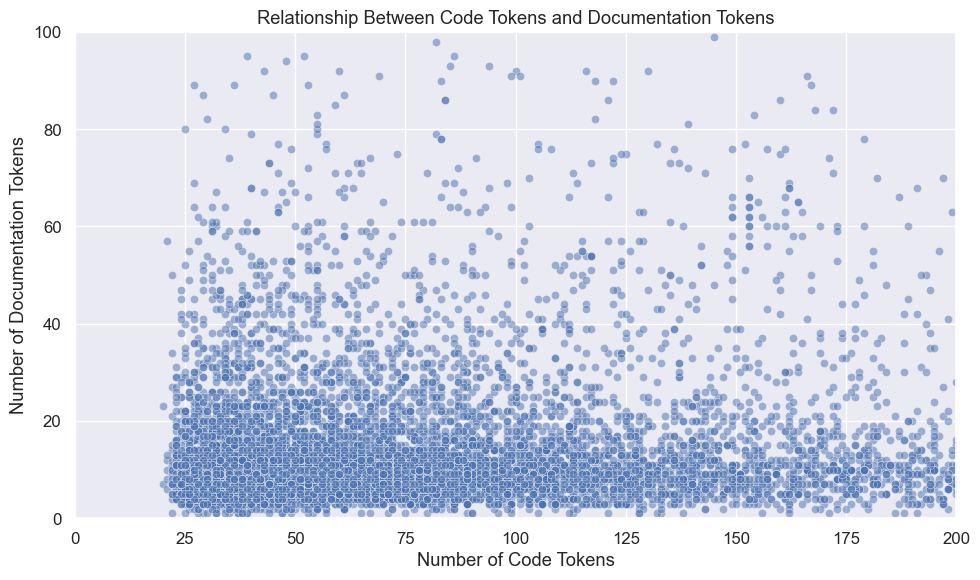


Correlation between code tokens and documentation tokens: 0.1150


In [30]:

# Figure 1: Distribution of repositories
plt.figure(figsize=(12, 6))
repo_counts.plot(kind='bar')
plt.title('Top 10 Repositories in the Dataset')
plt.xlabel('Repository Name')
plt.ylabel('Number of Functions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('repo_distribution.png')
plt.close()

# Figure 2: Documentation strings length
train_df['doc_length'] = train_df['func_documentation_string'].apply(lambda x: len(x) if x else 0)
plt.figure(figsize=(10, 6))
sns.histplot(train_df['doc_length'], bins=50, kde=True)
plt.title('Distribution of Documentation String Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.axvline(train_df['doc_length'].median(), color='red', linestyle='--', 
            label=f'Median: {train_df["doc_length"].median():.0f}')
plt.axvline(train_df['doc_length'].mean(), color='green', linestyle='--', 
            label=f'Mean: {train_df["doc_length"].mean():.0f}')
plt.xlim(0,1500)
plt.legend()
plt.tight_layout()
plt.savefig('doc_length_distribution.png')
plt.close()

# Figure 3: Code strings length(in lines)
train_df['code_lines'] = train_df['func_code_string'].apply(lambda x: len(x.split('\n')) if x else 0)
plt.figure(figsize=(10, 6))
sns.histplot(train_df['code_lines'], bins=50, kde=True)
plt.title('Distribution of Function Lengths')
plt.xlabel('Number of Lines')
plt.ylabel('Frequency')
plt.axvline(train_df['code_lines'].median(), color='red', linestyle='--', 
            label=f'Median: {train_df["code_lines"].median():.0f}')
plt.axvline(train_df['code_lines'].mean(), color='green', linestyle='--', 
            label=f'Mean: {train_df["code_lines"].mean():.0f}')
plt.xlim(0,250)
plt.legend()
plt.tight_layout()
plt.savefig('code_length_distribution.png')
plt.close()

# Figure 4: Code length vs. documentation length
plt.figure(figsize=(10, 6))
sns.scatterplot(x='code_lines', y='doc_length', data=train_df, alpha=0.5)
plt.title('Relationship Between Code Length and Documentation Length')
plt.xlabel('Code Length (lines)')
plt.ylabel('Documentation Length (characters)')
plt.xlim(0,600)
plt.tight_layout()
plt.savefig('code_vs_doc_length.png')
plt.close()

# Figure 5: Function names analysis
def extract_prefix(func_name, max_length=5):
    """Extract the prefix of a function name up to max_length characters"""
    # Get just the function name without module path
    name = func_name.split('.')[-1]
    # Extract prefix
    match = re.match(r'^([a-z]+)_', name)
    if match:
        return match.group(1)
    return None

# Extract prefixes from function names
train_df['func_prefix'] = train_df['func_name'].apply(extract_prefix)
# Count most common prefixes
prefix_counts = train_df['func_prefix'].dropna().value_counts().head(15)

plt.figure(figsize=(12, 6))
prefix_counts.plot(kind='bar')
plt.title('Most Common Function Name Prefixes')
plt.xlabel('Prefix')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('function_prefix_counts.png')
plt.close()

# Figure 6: Check for documentation presence
train_df['has_documentation'] = train_df['func_documentation_string'].apply(lambda x: len(x) > 0 if x else False)
doc_presence_counts = train_df['has_documentation'].value_counts()

# Fix: Create the values and labels lists explicitly
pie_values = doc_presence_counts.values
pie_labels = ['Has Documentation' if idx else 'No Documentation' for idx in doc_presence_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(pie_values, labels=pie_labels, 
        autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title('Percentage of Functions with Documentation')
plt.savefig('documentation_presence.png')
plt.show()
plt.close()

# Figure 7: Documentation quality - simple model based on length
def doc_quality_category(length):
    if length == 0:
        return 'None'
    elif length < 50:
        return 'Brief'
    elif length < 200:
        return 'Moderate'
    else:
        return 'Detailed'

train_df['doc_quality'] = train_df['doc_length'].apply(doc_quality_category)
quality_counts = train_df['doc_quality'].value_counts()

plt.figure(figsize=(10, 6))
quality_counts.plot(kind='bar')
plt.title('Documentation Quality Distribution')
plt.xlabel('Documentation Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('documentation_quality.png')
plt.show()
plt.close()

# Figure 8: Token counts
train_df['code_token_count'] = train_df['func_code_tokens'].apply(len)
train_df['doc_token_count'] = train_df['func_documentation_tokens'].apply(len)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='code_token_count', y='doc_token_count', data=train_df, alpha=0.5)
plt.title('Relationship Between Code Tokens and Documentation Tokens')
plt.xlabel('Number of Code Tokens')
plt.ylabel('Number of Documentation Tokens')
plt.xlim(0, 200)  # Restrict x-axis to 0-200 tokens
plt.ylim(0, 100)  # Restrict y-axis to 0-100 tokens
plt.tight_layout()
plt.savefig('token_counts_relationship.png')
plt.show()
plt.close()

# Calculate correlation
token_correlation = train_df['code_token_count'].corr(train_df['doc_token_count'])
print(f"\nCorrelation between code tokens and documentation tokens: {token_correlation:.4f}")


In [29]:

# Summary
print("\n--- Data Exploration Summary ---")
print(f"Total Python functions in training set: {len(dataset['train'])}")
print(f"Average documentation length: {train_df['doc_length'].mean():.1f} characters")
print(f"Average code length: {train_df['code_lines'].mean():.1f} lines")
print(f"Percentage of functions with documentation: {train_df['has_documentation'].mean() * 100:.1f}%")
print(f"Correlation between code length and documentation length: {train_df['code_lines'].corr(train_df['doc_length']):.4f}")
print(f"Most common function prefix: {prefix_counts.index[0]} ({prefix_counts.iloc[0]} occurrences)")

print("\nExploration complete! 8 visualizations have been created.")


--- Data Exploration Summary ---
Total Python functions in training set: 412178
Average documentation length: 289.0 characters
Average code length: 26.7 lines
Percentage of functions with documentation: 100.0%
Correlation between code length and documentation length: 0.5300
Most common function prefix: get (885 occurrences)

Exploration complete! 8 visualizations have been created.
